In [586]:
from bargal.dataset.load import load_dataset
from bargal.images.client import GalaxyImageClient
from bargal.images.transformations import (
    make_image_pipeline,
    adaptive_normalize_transformer,
    bilateral_filter_transformer,
    log_transformer,
    center_zoom_transformer, remove_background_transformer, normalize_transformer, sqrt_transformer, power_transformer,
    median_blur_transformer, ImageTransformer, squared_transformer
)
from bargal.models import Observation
from bargal.preprocessing import GRDiffProcessor, ImageProcessor, GRRatioProcessor

import matplotlib.pyplot as plt

In [587]:
img_client = GalaxyImageClient(storage_path=r'D:\datasets\bargal\images')

In [588]:
df = load_dataset('../data/dataset.csv')

In [589]:
barred_galaxies = df[df.Bars == 1].sample(5)
observations = [img_client.get_as_observation(g, use_fits=True, skip_rgb=False) for g in barred_galaxies.to_dict(orient='records')]

In [590]:
log_and_zoom = make_image_pipeline(
    # log_transformer(),
    normalize_transformer(),
    center_zoom_transformer(3),
)

def process_and_compare(_obs: list[Observation], p: ImageProcessor):
    n = len(_obs)

    fig, ax = plt.subplots(2, n, figsize=(4*n, 8))

    for i, obs in enumerate(_obs):
        ax[0][i].imshow(obs.rgb_repr)
        ax[0][i].axis('off')

        ax[1][i].imshow(p.preprocess(obs), cmap='gray', norm=plt.Normalize(vmin=0, vmax=1))
        ax[1][i].axis('off')

    plt.show()

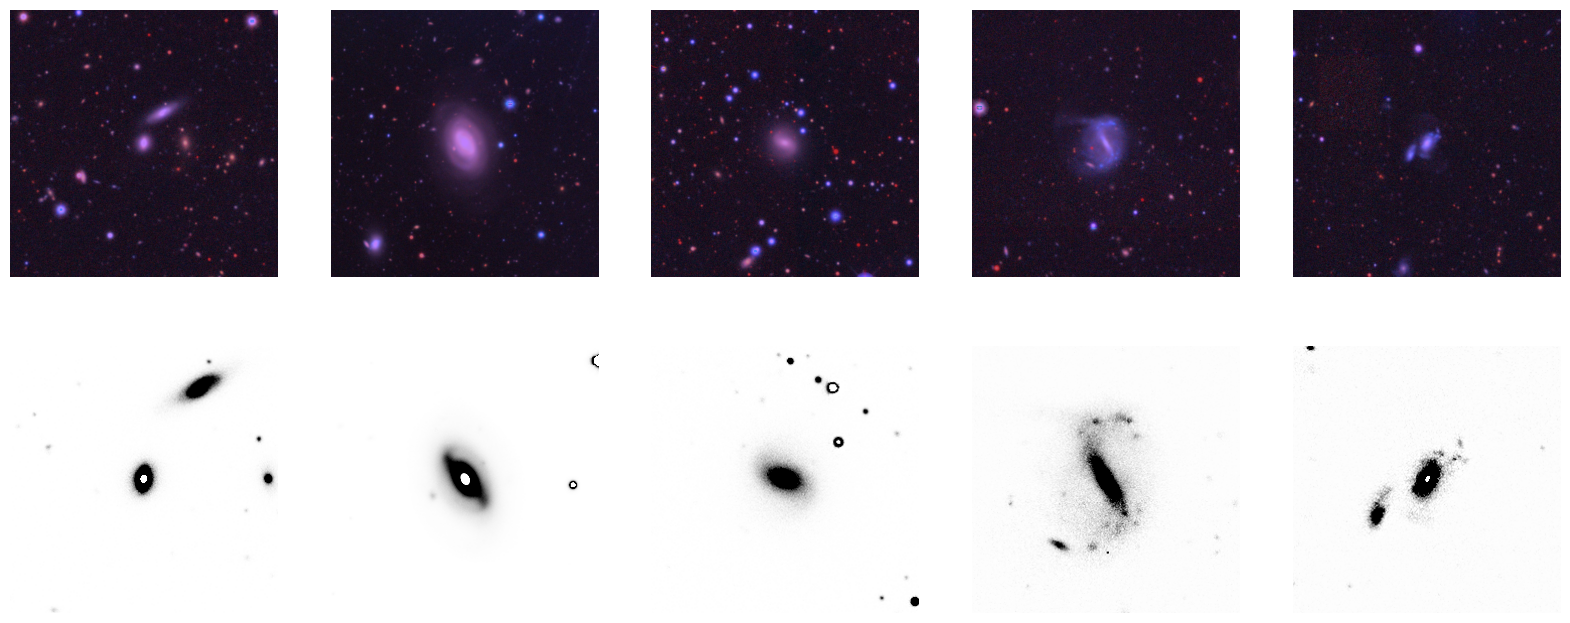

In [628]:
g_r_transform = make_image_pipeline(
        squared_transformer(),
    )

processor = GRDiffProcessor(
    g_transform=g_r_transform,
    r_transform=g_r_transform,
    result_transform=make_image_pipeline(
        center_zoom_transformer(3),
        adaptive_normalize_transformer(),
    )
)

process_and_compare(observations, processor)

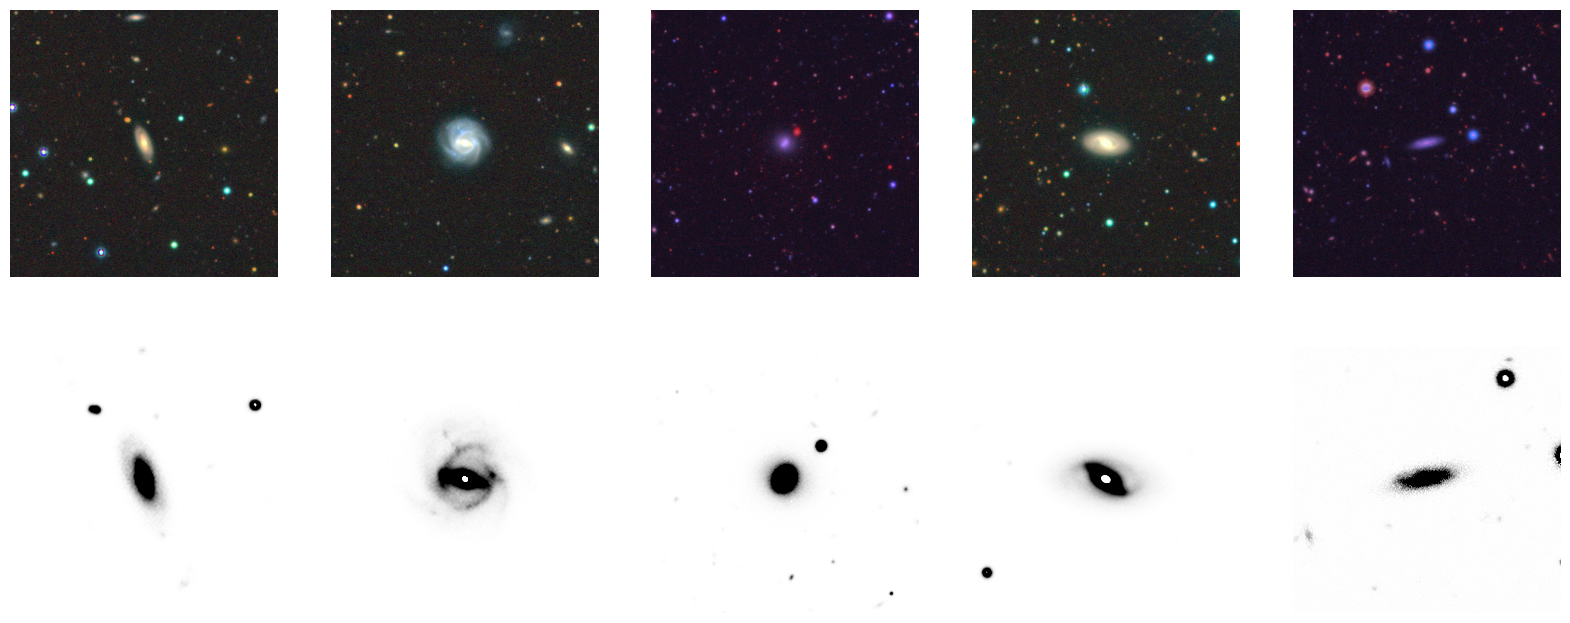

In [638]:
barred_galaxies = df[df.Bars == 1].sample(5)
observations = [img_client.get_as_observation(g, use_fits=True, skip_rgb=False) for g in barred_galaxies.to_dict(orient='records')]

process_and_compare(observations, processor)

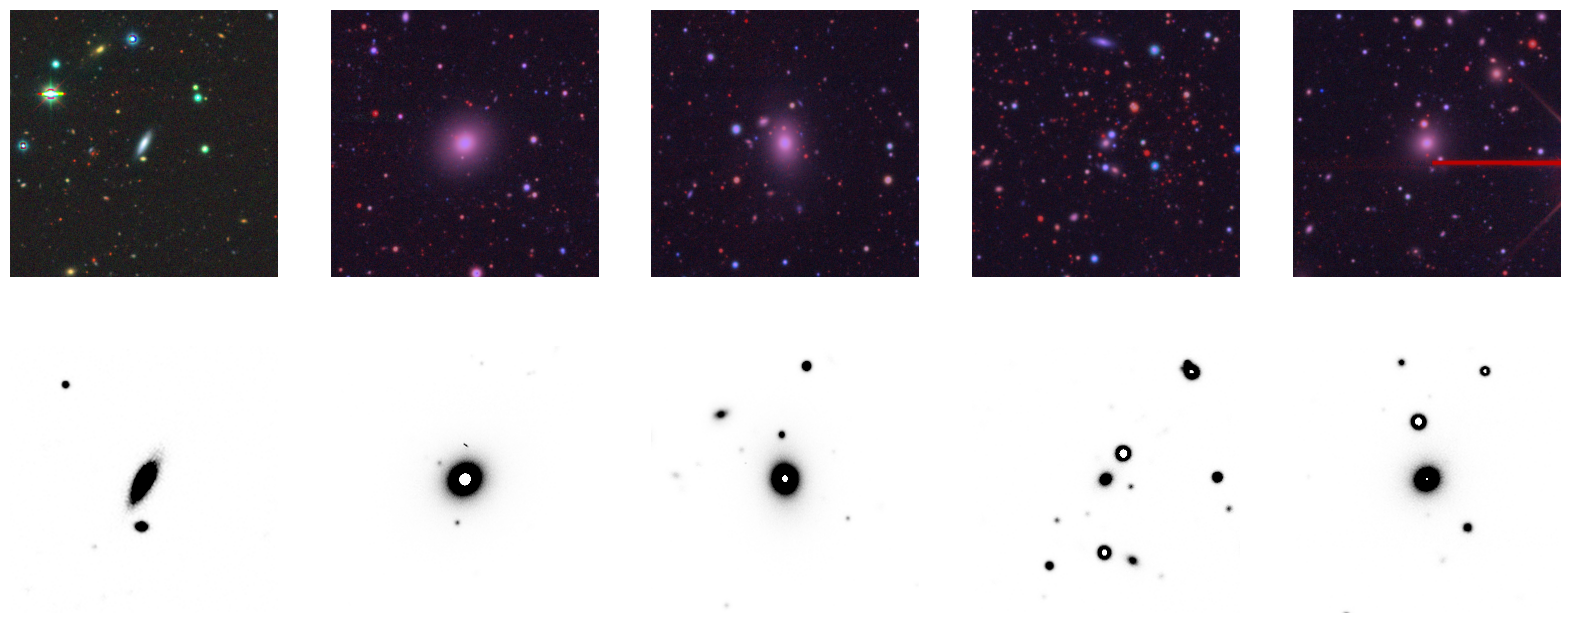

In [637]:
non_barred_galaxies = df[df.Bars == 0].sample(5)
observations_no_bar = [img_client.get_as_observation(g, use_fits=True, skip_rgb=False) for g in non_barred_galaxies.to_dict(orient='records')]

process_and_compare(observations_no_bar, processor)